In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
import argparse, time, os, lzma, io
from datetime import datetime
from pathlib import Path

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch.nn.functional as F
import torch.distributions as dist

import matplotlib.pyplot as plt

print(torch.__version__)

2.10.0+cu128


In [10]:
##import pkgutil

##for module in pkgutil.iter_modules():
##  print(module.name)

In [11]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

torch.set_default_dtype(torch.float64)

In [12]:
import torch
from torch.utils.data import Dataset, DataLoader

class Pi_dataset(Dataset):

    def __init__(self, filename):

        with open(filename, 'r') as f:

            line_count = sum(1 for line in f)

            print(line_count)

            self.data = torch.zeros((line_count, 1), dtype=torch.float64)

            self.labels = torch.zeros((line_count, 1), dtype=torch.float64)

        with open(filename, 'r') as f:

            for i, line in enumerate(f):

                a = line.strip().split(',')

                self.data[i] = float(a[0])

                self.labels[i] = float(a[1])

    def __len__(self):

        return len(self.data)

    def __getitem__(self, idx):

        return self.data[idx], self.labels[idx]

In [13]:
class Linear_model_deterministic(nn.Module):

    def __init__(self, n: int, udist: tuple[int, int], random_seed: int):

        super().__init__()

        self.linear_relu_stack = nn.Sequential(
            nn.Linear(1, n),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(n, n),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(n, 1)
        )

        nn.init.uniform_(self.linear_relu_stack[0].weight, a=-udist[0], b=udist[1])
        nn.init.uniform_(self.linear_relu_stack[2].weight, a=-udist[0], b=udist[1])
        nn.init.uniform_(self.linear_relu_stack[4].weight, a=-udist[0], b=udist[1])

    def forward(self, x: torch.Tensor):

        logits = self.linear_relu_stack(x)

        out = torch.sigmoid(logits)

        return out, 0

In [14]:
def run_training_loop(model: nn.Module,
                      train_dl: DataLoader,
                      test_dl: DataLoader,
                      epochs: int,
                      filename: str,
                      kl_loss_ratio: float):

    ##  Define loss.

    loss = nn.BCELoss()

    ##  Define parameter optimisation mechanism.

    ##  optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # while time.time() - start_time < 300:

    ##  Train either for fixed period of time or fixed quantity of epochs.

    start_time = time.time()
    ##  Output training start time.

    print(datetime.now().strftime("%H:%M:%S"))

    ##  Run train-test sequence.

    for t in range(epochs):

        print(f"Training...")

        train(train_dl, model, loss, optimizer, kl_loss_ratio)

        print(f"Testing...")

        test(test_dl, model, loss, kl_loss_ratio)

    ##  Output training time.

    print(f"{time.time() - start_time}s")

    # print(model.state_dict())

    ##  Save model params to plaintext.

    # with open("model_params.post", "w") as f:

    #     state_dict = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()

    #     f.write(str(state_dict))

    ##  Generate timestamp and store weights for later loading back.

    print(filename)

    torch.save(model.state_dict(), filename)


def train(dl: DataLoader,
          model: nn.Module,
          loss: nn.Module,
          optimizer: torch.optim.Optimizer,
          kl_loss_ratio: float):

    ##  Put model into training mode; ensures gradient tracking.

    model.train()

    for batch, (X, y) in enumerate(dl):

        X, y = X.to(device), y.to(device)

        ##  Run X through model, generate prediction.

        y_hat, kl_model = model(X)

        ##  Calculate error of prediction.

        loss_res = (1 - kl_loss_ratio) * loss(y_hat, y) + (kl_loss_ratio * kl_model)

        ##  loss_res = loss(y_hat, y)

        ##  compute gradients numerically via backpropagation, back to
        ##  leaf nodes of graph.

        loss_res.backward()

        ##  Iterate parameters.

        optimizer.step()

        ##  Reset gradients within graph.

        optimizer.zero_grad()

        # optimizer.debug_off()

        if batch % 1000 == 0:

            pass

            # print(torch.stack([X, y, y_hat], dim=0).T)

            ##  It is not necessary to know the exact parameter
            ##  values, just that they are changing.

            # optimizer.debug_off()

            # print(model.state_dict().keys())

            # print(model.state_dict()['linear_relu_stack.0.weight_mu'].sum(),
            #       model.state_dict()['linear_relu_stack.0.rho_weight'].sum(),
            #       model.state_dict()['linear_relu_stack.0.mu_bias'].sum(),
            #       model.state_dict()['linear_relu_stack.0.rho_bias'].sum(),
            #       model.state_dict()['linear_relu_stack.2.weight_mu'].sum(),
            #       model.state_dict()['linear_relu_stack.2.rho_weight'].sum(),
            #       model.state_dict()['linear_relu_stack.2.mu_bias'].sum(),
            #       model.state_dict()['linear_relu_stack.2.rho_bias'].sum(),
            #       model.state_dict()['linear_relu_stack.4.weight_mu'].sum(),
            #       model.state_dict()['linear_relu_stack.4.rho_weight'].sum(),
            #       model.state_dict()['linear_relu_stack.4.mu_bias'].sum(),
            #       model.state_dict()['linear_relu_stack.4.rho_bias'].sum(),
            #       )

            # print(model.state_dict()['linear_relu_stack.0.weight_mu'][0])
            # print(model.state_dict()['linear_relu_stack.0.weight_mu'][0].grad)

            # print(torch.round(y_hat), y)

            # print(loss_res.item())

            # current = (batch + 1) * len(X)

            # print(f"[{current:>5d}/{len(train_dl.dataset):>5d}]")

            # print(f"loss_1: {loss_1:>7f}  [{current:>5d}/{size:>5d}]")


def test(dl: DataLoader, model: nn.Module, loss: nn.Module, kl_loss_ratio: float):

    ##  Trigger utilisation mode, whilst maintaining Dropout functionality.

    model.eval()

    for m in model.modules():

      if m.__class__.__name__.startswith('Dropout'):

        m.train()

    test_loss, correct = 0, 0

    with torch.no_grad():

        for X, y in dl:

            X, y = X.to(device), y.to(device)

            y_hat, kl_model = model(X)

            ##  Calculate error of prediction.

            ##  print("BCE: ", loss(y_hat, y))

            ##  print("KL: ", kl_model)

            loss_res = (1 - kl_loss_ratio) * loss(y_hat, y) + (kl_loss_ratio * kl_model)

            test_loss += loss_res.item()

            # correct += (y_hat.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= len(dl)

    # correct /= len(dl.dataset)

    print(f"{test_loss:>8f}")

In [34]:
def run_utilisation_loop_batch(model: nn.Module,
                               batch_name: str,
                               sample_quantity: int):

    print("loop batch")

    directory = Path('./params/')

    # Find all files with batch_name in filename

    for file in directory.glob(f"model_params*{batch_name}*xz"):

        print(str(file))

        if file.is_file():

            dist_metadata = str(file).split(batch_name)[-1].replace('.xz','')

            graph_filename = f"{batch_name}{dist_metadata}"

            params_path = f"./{str(file)}"

            run_utilisation_loop_once(model, params_path, graph_filename)

            # Do something with the file


def run_utilisation_loop_once(model: nn.Module, params_path: str, graph_filename: str, sample_quantity: int):

    ##  Decompress to memory.

    # with lzma.open(params_path, 'rb') as f:

    #     decompressed_data = f.read()

    ##  Load params.

    # checkpoint = torch.load(io.BytesIO(decompressed_data),

    checkpoint = torch.load(params_path,
                           weights_only = True,
                           map_location=torch.device('cpu')
                           )

    old_state_dict = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint

    print(old_state_dict)

    ##  Fix naming scheme and load module.

    model.load_state_dict(
                {k.replace('module.', '', 1): v for k, v in old_state_dict.items()}
    )

    ##  Trigger utilisation mode, whilst maintaining Dropout functionality.

    model.eval()

    for m in model.modules():

      if m.__class__.__name__.startswith('Dropout'):

        m.train()

    res = []

    interval = 1 / (2 ** 6)

    dl = DataLoader(
                TensorDataset(
                    torch.arange(1.57, 4.71 + interval, interval)
                ),
                batch_size = 1,
                shuffle = False
    )

    with torch.no_grad():

        ##################  Deterministic single-sample loop.

        # outputs_set = []

        # for batch, (X,) in enumerate(dl):

        #     X = X.to(device)

        #     # print(X)

        #     ##  Run X through model, generate prediction.

        #     y_hat, _ = model(X)

        #     print(X.item(), y_hat.item())

        #     outputs_set.append((X.item(), y_hat.squeeze(0).item()))

        ##################  MC-Dropout multi-sample loop.

        outputs_set = ()

        for batch, (X,) in enumerate(dl):

            X = X.to(device)

            # print(X)

            ##  Run X through model, generate prediction.

            sample_set = ()

            for _ in range(sample_quantity):

                y_hat_sample, _ = model(X)

                sample_set = sample_set + (y_hat_sample,)

            print(sample_set)

            ##  Take mean of samples.

            y_hat = torch.stack(sample_set).mean(dim=0)

            print(f"p({X.item()}) = {y_hat.item()}")

            ##  Store for later plotting

            outputs_set = outputs_set + ((X.item(), y_hat.squeeze(0).item()),)

        ##################

        x, y = zip(*outputs_set)

        with open(f"{graph_filename}.txt", "w") as file:

            file.write("\n".join(map(lambda y_i: str(y_i), y)) + "\n")

        plt.figure(figsize=(6, 4))

        # plt.plot(
        #             x, y,
        #             marker='o',
        #             markersize=4,          # small dots
        #             markerfacecolor='black',
        #             markeredgecolor='black',
        #             linewidth=0.8,         # thin connecting line
        #             color='black',
        #             label='Trajectory'
        # )

        plt.scatter(
                    x, y,
                    color='black',          # point colour
                    edgecolor='black',          # optional border around each marker
                    s=10,                       # marker size
                    label='Samples'
        )

        plt.xlabel('Input value')
        plt.ylabel('Probability of π classification')
        plt.grid(True, ls='--', lw=0.5, alpha=0.7)
        plt.tight_layout()

        plt.tight_layout()

        plt.savefig(f"{graph_filename}.pdf", dpi=300)
        #plt.show()

        plt.close()

        return graph_filename



In [16]:
def run_model(env: dict[str, str | int | float]):

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    ##  Setup filename to store params to.

    filename = f"model_params_batch_{env['batch_n']}_epochs_{env['training_epochs']}_{env['params_name']}"

    file_path = os.path.join(*["/content", "drive", "MyDrive", filename])

    print(file_path)

    ##  Define model.

    print(env)

    if env["dropout_p"] == 0:

        print('Building deterministic model.')

        model = Linear_model_deterministic(
                    env["neurons_n"],
                    env["udist"],
                    env["random_seed"],
        ).to(device)

    else:

        print('Building MC dropout model.')

        model = Linear_model_mcdrop(
                    env["neurons_n"],
                    env["udist"],
                    env["random_seed"],
                    env["dropout_p"]
        ).to(device)

    ##  Ensure multiple GPUs used if available.

    if torch.cuda.device_count() > 1:

        print(f"Using {torch.cuda.device_count()} GPUs!")

        model = nn.DataParallel(model, device_ids=[0, 1])

    ##  Either load params or load training data.

    print(env)

    if env["params_load"] is not None:

        run_utilisation_loop_once(
                    model,
                    env["params_load"],
                    env["params_load"].split('/')[-1] + "_plot",
                    env["sample_quantity"]
        )

    elif env["params_load_batch"] is not None:

        run_utilisation_loop_batch(
                    model,
                    env["params_load_batch"],
                    env["sample_quantity"]
        )

    else:

        train_dl = DataLoader(
                    Subset(
                        Pi_dataset("/content/drive/MyDrive/modules_work/COMP30040/datasets/pi_dataset_40000.txt"),
                        range(40000)
                    ),
                    batch_size = env["batch_n"],
                    shuffle=True
        )

        test_dl = DataLoader(
                    Subset(
                        Pi_dataset("/content/drive/MyDrive/modules_work/COMP30040/datasets/pi_dataset_8000.txt"),
                        range(8000)
                    ),
                    batch_size = env["batch_n"],
                    shuffle=True
        )

        if env["params_checkpoint"] is not None:

            print("Loading checkpoint.")

            torch.load(env["params_checkpoint"])

        run_training_loop(model,
                          train_dl,
                          test_dl,
                          env["training_epochs"],
                          file_path,
                          env["kl_loss_ratio"])


In [17]:
class Linear_model_mcdrop(nn.Module):

    def __init__(self, n: int, udist: tuple[int, int], random_seed: int, p: float = 0.2):

        print(n)

        print(udist)

        super().__init__()

        self.linear_relu_stack = nn.Sequential(
            nn.Linear(1, n),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(n, n),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(n, 1)
        )

        nn.init.uniform_(self.linear_relu_stack[0].weight, a=-udist[0], b=udist[1])
        nn.init.uniform_(self.linear_relu_stack[3].weight, a=-udist[0], b=udist[1])
        nn.init.uniform_(self.linear_relu_stack[6].weight, a=-udist[0], b=udist[1])

    def forward(self, x: torch.Tensor):

        logits = self.linear_relu_stack(x)

        out = torch.sigmoid(logits)

        return out, 0

In [28]:
# env_train_det = {
#             "neurons_n": 1024,
#             "batch_n": 64,
#             "training_epochs": 50,
#             "params_name": "det",       ##  Filename to store params to.
#             "params_load": None,        ##  Filename to load specific set of params from.
#             "params_load_batch": None,  ##  Filename to wildcard match a multiple sets of params.
#             "random_seed": 239852,
#             "mu_w_init": 0.0,
#             "mu_b_init": 0.0,
#             "rho_w_init": 0.0,
#             "rho_b_init": 0.0,
#             "kl_loss_ratio": 0.0,       ##  Ratio to consider KL-divergence loss during sum of loss functions.
#             "udist": (0.1, 0.1)         ##  Uniform distribution params, in the case of deterministic model.
# }

env_train_mcdrop = {
            "neurons_n": 1024,
            "batch_n": 256,
            "training_epochs": 2,
            "params_name": "mcdrop_0.2",  ##  Filename to store params to.
            "params_load": None,          ##  Filename to load specific set of params from, for utilisation.
            "params_load_batch": None,    ##  Filename to wildcard match a multiple sets of params.
            "params_checkpoint": None,    ##  "/content/drive/MyDrive/model_params_batch_16_epochs_34_mcdrop",
            "random_seed": 239852,
            "mu_w_init": 0,
            "mu_b_init": 0,
            "rho_w_init": 0,
            "rho_b_init": 0,
            "kl_loss_ratio": 0,           ##  Ratio to consider KL-divergence loss during sum of loss functions.
            "udist": (0.2, 0.2),          ##  Uniform distribution params, if not (0, 0) will trigger deterministic model.
            "dropout_p": 0.8
}

#for k, v in env.items():
#            print(f"{k}: {v}")

torch.manual_seed(env_train_mcdrop["random_seed"])

udist_distribs = tuple(map(lambda x: 0.125 * x, tuple(range(1, 4))))

for udist in udist_distribs:

  for seed in (5453, 7876974563457, 67498896):

    env_train_mcdrop_tmp = env_train_mcdrop.copy()

    env_train_mcdrop_tmp["random_seed"] = seed

    env_train_mcdrop_tmp["udist"] = (udist, udist)

    env_train_mcdrop_tmp["params_name"] = f"mcdrop_seed_{seed}_udist_{udist}"

    run_model(env=env_train_mcdrop_tmp)

/content/drive/MyDrive/model_params_batch_256_epochs_2_mcdrop_seed_5453_udist_0.125
{'neurons_n': 1024, 'batch_n': 256, 'training_epochs': 2, 'params_name': 'mcdrop_seed_5453_udist_0.125', 'params_load': None, 'params_load_batch': None, 'params_checkpoint': None, 'random_seed': 5453, 'mu_w_init': 0, 'mu_b_init': 0, 'rho_w_init': 0, 'rho_b_init': 0, 'kl_loss_ratio': 0, 'udist': (0.125, 0.125), 'dropout_p': 0.8}
Building MC dropout model.
1024
(0.125, 0.125)
{'neurons_n': 1024, 'batch_n': 256, 'training_epochs': 2, 'params_name': 'mcdrop_seed_5453_udist_0.125', 'params_load': None, 'params_load_batch': None, 'params_checkpoint': None, 'random_seed': 5453, 'mu_w_init': 0, 'mu_b_init': 0, 'rho_w_init': 0, 'rho_b_init': 0, 'kl_loss_ratio': 0, 'udist': (0.125, 0.125), 'dropout_p': 0.8}
40000
8000
09:13:33
Training...
Testing...
0.599539
Training...
Testing...
0.368715
2.0941100120544434s
/content/drive/MyDrive/model_params_batch_256_epochs_2_mcdrop_seed_5453_udist_0.125
/content/drive/MyDriv

In [35]:
filename_mcdrop = f"/content/drive/MyDrive/model_params_batch_{env_train_mcdrop['batch_n']}_epochs_{env_train_mcdrop['training_epochs']}_{env_train_mcdrop['params_name']}"

env_load_mcdrop = {
            "params_name": None,
            "params_load": filename_mcdrop,
            "params_load_batch": None,
            "sample_quantity": 50
}

env_utilise_mcdrop = env_train_mcdrop | env_load_mcdrop

for udist in udist_distribs:

  for seed in (5453, 7876974563457, 67498896):

    env_utilise_mcdrop_tmp = env_train_mcdrop.copy()

    env_utilise_mcdrop_tmp = env_train_mcdrop_tmp | env_load_mcdrop

    env_utilise_mcdrop_tmp["params_load"] = f"/content/drive/MyDrive/model_params_batch_{env_train_mcdrop['batch_n']}_epochs_{env_train_mcdrop['training_epochs']}_mcdrop_seed_{seed}_udist_{udist}"

    for k, v in env_utilise_mcdrop_tmp.items():
            print(f"{k}: {v}")

    run_model(env_utilise_mcdrop_tmp)

neurons_n: 1024
batch_n: 256
training_epochs: 2
params_name: None
params_load: /content/drive/MyDrive/model_params_batch_256_epochs_2_mcdrop_seed_5453_udist_0.125
params_load_batch: None
params_checkpoint: None
random_seed: 67498896
mu_w_init: 0
mu_b_init: 0
rho_w_init: 0
rho_b_init: 0
kl_loss_ratio: 0
udist: (0.375, 0.375)
dropout_p: 0.8
sample_quantity: 50
/content/drive/MyDrive/model_params_batch_256_epochs_2_None
{'neurons_n': 1024, 'batch_n': 256, 'training_epochs': 2, 'params_name': None, 'params_load': '/content/drive/MyDrive/model_params_batch_256_epochs_2_mcdrop_seed_5453_udist_0.125', 'params_load_batch': None, 'params_checkpoint': None, 'random_seed': 67498896, 'mu_w_init': 0, 'mu_b_init': 0, 'rho_w_init': 0, 'rho_b_init': 0, 'kl_loss_ratio': 0, 'udist': (0.375, 0.375), 'dropout_p': 0.8, 'sample_quantity': 50}
Building MC dropout model.
1024
(0.375, 0.375)
{'neurons_n': 1024, 'batch_n': 256, 'training_epochs': 2, 'params_name': None, 'params_load': '/content/drive/MyDrive/mo

In [20]:
# filename_det = f"/content/drive/MyDrive/model_params_batch_{env_train_det['batch_n']}_epochs_{env_train_det['training_epochs']}_{env_train_det['params_name']}"

# env_load_det = {
#             "params_name": None,
#             "params_load": filename_det,
#             "params_load_batch": None,
#             "sample_quantity": 10
# }

# print(filename_det)

# env_utilise_det = env_train_det | env_load_det

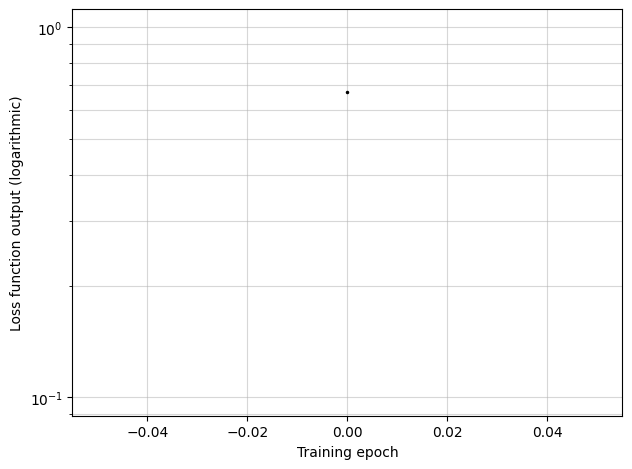

In [21]:
loss_f_out = [
  0.6702
]

# 2. Generate ascending integer values for the x-axis
# This creates a sequence from 0 to 9 based on the data length
x_values = range(len(loss_f_out))

# 3. Create the plot
plt.plot(x_values, loss_f_out, marker='o', markersize=1.5, linestyle='-', linewidth=0.5, color='black')

# 4. Add labels and title
plt.xlabel('Training epoch')
plt.ylabel('Loss function output (logarithmic)')

plt.tight_layout()

plt.yscale('log')

plt.grid(True, which="both", ls="-", alpha=0.5)

#plt.show()

plt.savefig('loss_func_out_per_epoch.pdf')